# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : 
- Alumno 2 :

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from collections import Counter
import warnings

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | Dispositivo: {device}")

c:\Users\nicom\Documents\Antigravity\tuia-face-recognition-app\venv_face\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.2.2+cpu | Dispositivo: cpu


In [ ]:
lfw = fetch_lfw_people(min_faces_per_person=20, color=True, resize=1.0)

X_lfw = lfw.images    # (n_samples, 125, 94, 3) float en [0, 1]
y_lfw = lfw.target     # etiquetas numéricas
NOMBRES = lfw.target_names

print(f"Total de imágenes: {X_lfw.shape[0]}")
print(f"Cantidad de personas: {len(NOMBRES)}")
print(f"Tamaño de imagen: {X_lfw.shape[1:3]}")
print(f"Rango de valores: [{X_lfw.min():.2f}, {X_lfw.max():.2f}]")

Total de imágenes: 3023
Cantidad de personas: 62
Tamaño de imagen: (125, 94)
Rango de valores: [0.00, 1.00]


In [18]:
def lfw_to_pil(img_array):
    """Convierte una imagen LFW (float [0,1]) a PIL RGB."""
    return Image.fromarray((img_array * 255).astype(np.uint8))

In [ ]:
detector = MTCNN(image_size=160, margin=20, keep_all=True, device=device)
print(f"MTCNN inicializado en {device}")

# Modelo de embeddings faciales
modelo = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print(f"\nInceptionResnetV1 cargado | Embedding: 512 dimensiones")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.1f}M")

MTCNN inicializado en cpu

InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M


In [ ]:
# Extraer embeddings para todas las imágenes seleccionadas
# Pipeline: imagen → MTCNN (crop+align) → InceptionResnetV1 → embedding 512-d
embeddings = []
etiquetas = []
imagenes_ok = []  # guardamos las imágenes para visualizar después

print("Extrayendo embeddings...")
for i in range(len(X_sel)):
    pil = lfw_to_pil(X_sel[i])
    cara = detector(pil)  # (N, 3, 160, 160) o None

    if cara is not None:
        # Tomar la primera cara detectada
        cara_input = cara[0].unsqueeze(0).to(device)  # (1, 3, 160, 160)

        with torch.no_grad():
            emb = modelo(cara_input)  # (1, 512), ya L2-normalizado

        embeddings.append(emb.cpu().squeeze().numpy())
        etiquetas.append(y_sel[i])
        imagenes_ok.append(X_sel[i])

    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(X_sel)} procesadas...")

embeddings = np.array(embeddings)
etiquetas = np.array(etiquetas)

print(f"\nEmbeddings extraídos: {len(embeddings)} de {len(X_sel)} imágenes")
print(f"Dimensión: {embeddings.shape[1]}")

Extrayendo embeddings...
  20/1240 procesadas...
  40/1240 procesadas...
  60/1240 procesadas...
  80/1240 procesadas...
  100/1240 procesadas...
  120/1240 procesadas...
  140/1240 procesadas...
  160/1240 procesadas...
  180/1240 procesadas...
  200/1240 procesadas...
  220/1240 procesadas...
  240/1240 procesadas...
  260/1240 procesadas...
  280/1240 procesadas...
  300/1240 procesadas...
  320/1240 procesadas...
  340/1240 procesadas...
  360/1240 procesadas...
  380/1240 procesadas...
  400/1240 procesadas...
  420/1240 procesadas...
  440/1240 procesadas...
  460/1240 procesadas...
  480/1240 procesadas...
  500/1240 procesadas...
  520/1240 procesadas...
  540/1240 procesadas...
  560/1240 procesadas...
  580/1240 procesadas...
  600/1240 procesadas...
  620/1240 procesadas...
  640/1240 procesadas...
  660/1240 procesadas...
  680/1240 procesadas...
  700/1240 procesadas...
  720/1240 procesadas...
  740/1240 procesadas...
  760/1240 procesadas...
  780/1240 procesadas...
  80

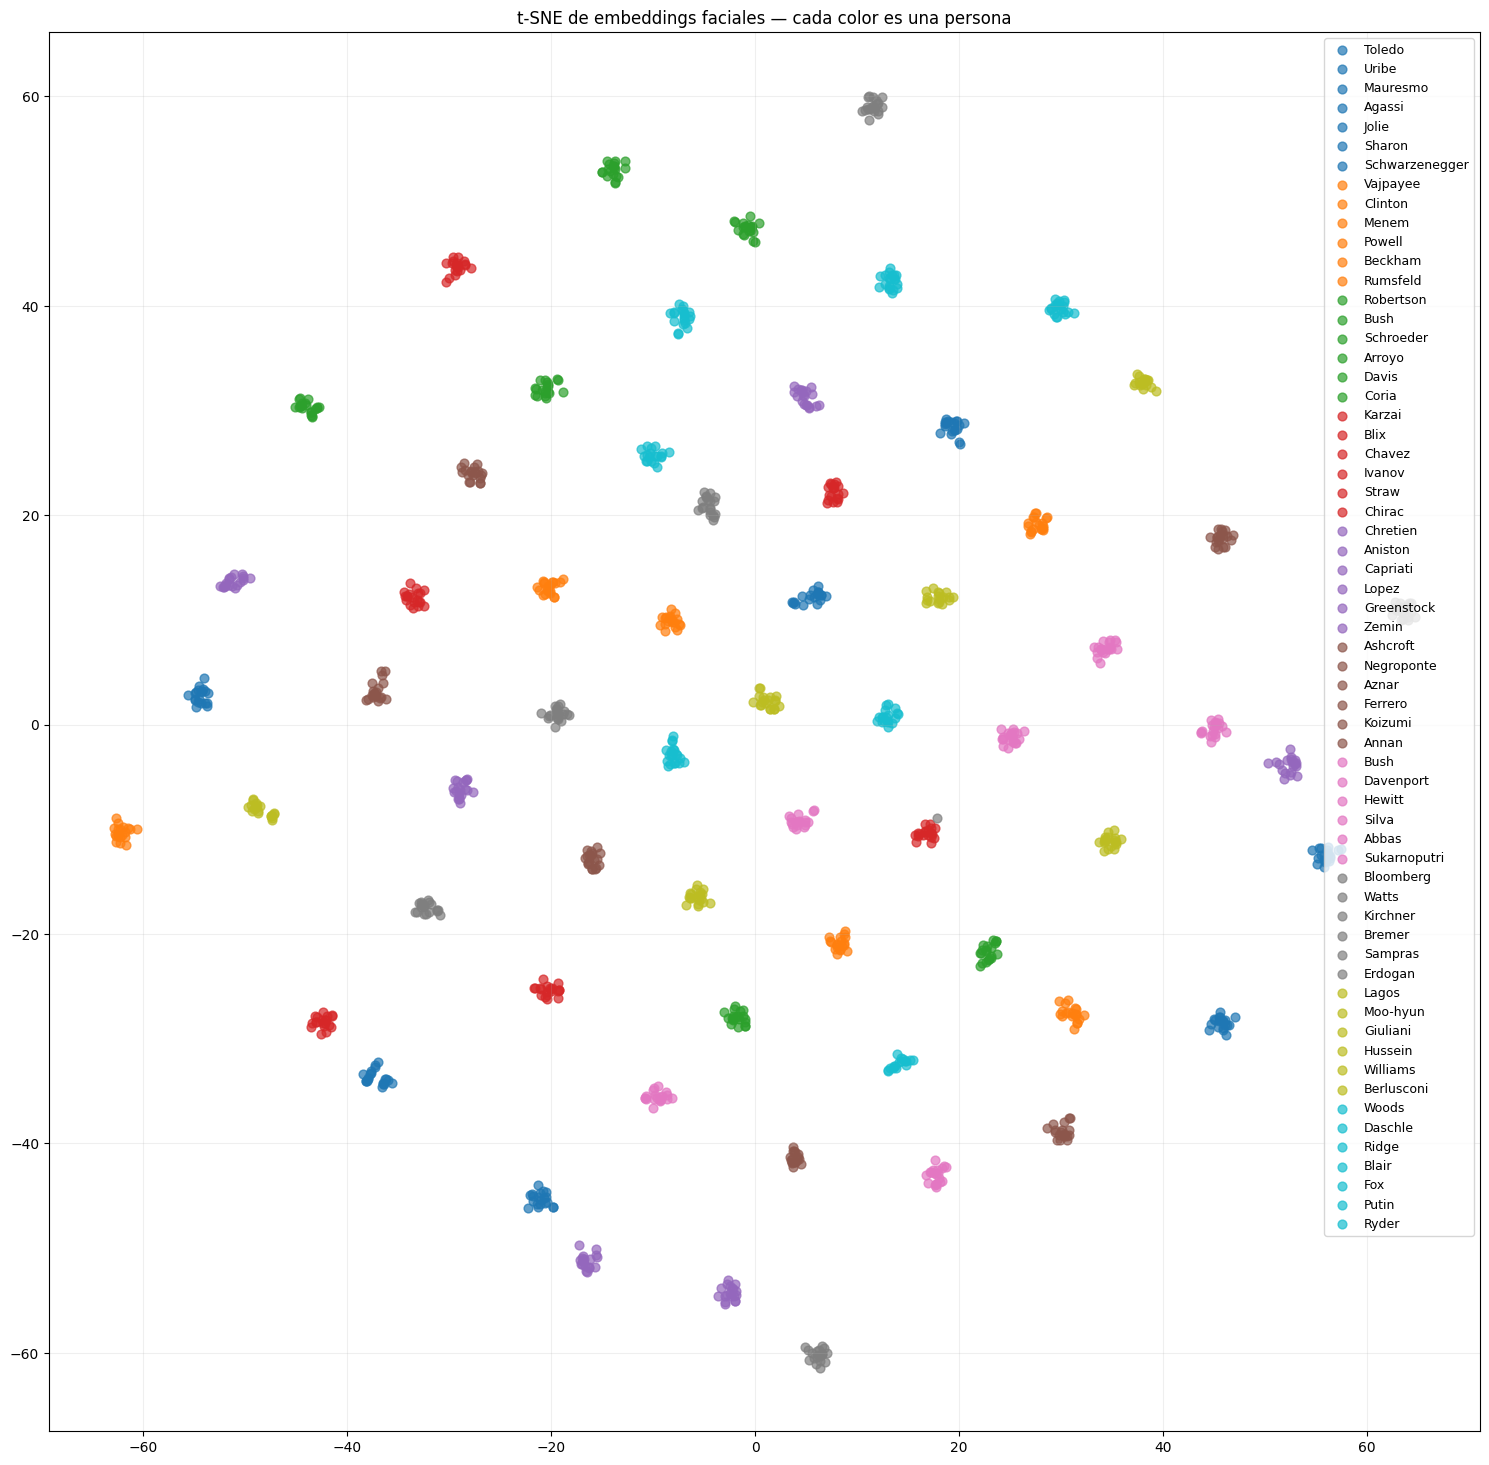

In [67]:
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(embeddings) - 1))
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(15, 15))
colores = plt.cm.tab10(np.linspace(0, 1, len(NOMBRES)))

for persona_id, nombre in enumerate(NOMBRES):
    mask = etiquetas == persona_id
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])

ax.legend(fontsize=9, loc='best')
ax.set_title("t-SNE de embeddings faciales — cada color es una persona")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [68]:
def verificar(emb1, emb2, umbral=0.6):
    """Verificación 1:1. Devuelve si son la misma persona + similitud."""
    sim = float(np.dot(emb1, emb2))
    return {"misma_persona": sim >= umbral, "similitud": round(sim, 4), "umbral": umbral}

In [69]:
# Dividir en galería y consultas (queries)
np.random.seed(42)

train_emb, train_labels, train_imgs = [], [], []
test_emb, test_label, test_imgs = [], [], []

for persona_id in range(len(NOMBRES)):
    idxs = np.where(etiquetas == persona_id)[0].copy()
    np.random.shuffle(idxs)
    n_gal = min(15, len(idxs) - 2)  # dejar al menos 2 para queries

    for idx in idxs[:n_gal]:
        train_emb.append(embeddings[idx])
        train_labels.append(persona_id)
        train_imgs.append(imagenes_ok[idx])

    for idx in idxs[n_gal:]:
        test_emb.append(embeddings[idx])
        test_label.append(persona_id)
        test_imgs.append(imagenes_ok[idx])

train_emb = np.array(train_emb)
train_labels = np.array(train_labels)
test_emb = np.array(test_emb)
test_label = np.array(test_label)

print(f"train: {len(train_emb)} embeddings")
print(f"test: {len(test_emb)} embeddings")

train: 930 embeddings
test: 288 embeddings


In [70]:
# Identificación: para cada query, buscar el más similar en la galería
# Similitud coseno en batch: producto punto de matrices
sims_matrix = qry_embs @ gal_embs.T  # (n_queries, n_galeria)

# Rank-1: el más similar
best_match_idx = sims_matrix.argmax(axis=1)
predicciones = gal_labels[best_match_idx]
accuracy_r1 = (predicciones == qry_labels).mean()

print(f"Accuracy Rank-1: {accuracy_r1:.3f} ({(predicciones == qry_labels).sum()}/{len(qry_labels)})")

Accuracy Rank-1: 1.000 (288/288)


In [ ]:
def pipeline_reconocimiento(img_pil, galeria_embs, galeria_labels, nombres, umbral=0.4):
    """
    Pipeline completo: imagen PIL → identidades detectadas.

    Retorna dict con:
      - caras: cantidad de caras detectadas
      - resultados: lista de dicts con identidad, similitud, bbox, confianza
    """
    
    # 1. Detección: encontrar caras
    boxes, probs, landmarks = detector.detect(img_pil, landmarks=True)
    if boxes is None:
        return {"caras": 0, "resultados": []}

    # 2. Crop + alineación
    caras_tensor = detector(img_pil)  # (N, 3, 160, 160)
    if caras_tensor is None:
        return {"caras": 0, "resultados": []}

    # 3. Extraer embeddings
    with torch.no_grad():
        embs = modelo(caras_tensor.to(device)).cpu().numpy()  # (N, 512)

    # 4. Identificación contra la galería
    resultados = []
    for i, (emb, box, prob) in enumerate(zip(embs, boxes, probs)):
        sims = emb @ galeria_embs.T
        best_idx = sims.argmax()
        best_sim = float(sims[best_idx])

        identidad = nombres[galeria_labels[best_idx]] if best_sim >= umbral else "Desconocido"

        resultados.append({
            "identidad": identidad,
            "similitud": round(best_sim, 4),
            "bbox": box,
            "confianza_deteccion": round(float(prob), 4),
        })

    return {"caras": len(resultados), "resultados": resultados}

print("Función pipeline_reconocimiento() definida.")

def pipeline_verificacion(img_pil, emb_referencia, umbral=0.6):
    """
    Verificación: detecta caras en la imagen y compara cada una
    contra un embedding de referencia.
    """
    caras_tensor = detector(img_pil)
    if caras_tensor is None:
        return {"verificado": False, "caras": 0, "similitudes": []}

    with torch.no_grad():
        embs = modelo(caras_tensor.to(device)).cpu().numpy()

    similitudes = [float(np.dot(emb, emb_referencia)) for emb in embs]
    verificado = any(s >= umbral for s in similitudes)

    return {
        "verificado": verificado,
        "caras": len(embs),
        "similitudes": [round(s, 4) for s in similitudes],
        "umbral": umbral,
    }

Función pipeline_reconocimiento() definida.
